## Аналіз A/B-тестів

Ви - аналітик даних в ІТ-компанії і до вас надійшла задача проаналізувати дані A/B тесту в популярній [грі Cookie Cats](https://www.facebook.com/cookiecatsgame). Це - гра-головоломка в стилі «з’єднай три», де гравець повинен з’єднати плитки одного кольору, щоб очистити дошку та виграти рівень. На дошці також зображені співаючі котики :)

Під час проходження гри гравці стикаються з воротами, які змушують їх чекати деякий час, перш ніж вони зможуть прогресувати або зробити покупку в додатку.

У цьому блоці завдань ми проаналізуємо результати A/B тесту, коли перші ворота в Cookie Cats було переміщено з рівня 30 на рівень 40. Зокрема, ми хочемо зрозуміти, як це вплинуло на утримання (retention) гравців. Тобто хочемо зрозуміти, чи переміщення воріт на 10 рівнів пізніше якимось чином вплинуло на те, що користувачі перестають грати в гру раніше чи пізніше з точки зору кількості їх днів з моменту встановлення гри.

Будемо працювати з даними з файлу `cookie_cats.csv`. Колонки в даних наступні:

- `userid` - унікальний номер, який ідентифікує кожного гравця.
- `version` - чи потрапив гравець в контрольну групу (gate_30 - ворота на 30 рівні) чи тестову групу (gate_40 - ворота на 40 рівні).
- `sum_gamerounds` - кількість ігрових раундів, зіграних гравцем протягом першого тижня після встановлення
- `retention_1` - чи через 1 день після встановлення гравець повернувся і почав грати?
- `retention_7` - чи через 7 днів після встановлення гравець повернувся і почав грати?

Коли гравець встановлював гру, його випадковим чином призначали до групи gate_30 або gate_40.

1. Для початку, уявімо, що ми тільки плануємо проведення зазначеного А/B-тесту і хочемо зрозуміти, дані про скількох користувачів нам треба зібрати, аби досягнути відчутного ефекту. Відчутним ефектом ми вважатимемо збільшення утримання на 1% після внесення зміни. Обчисліть, скільки користувачів сумарно нам треба аби досягнути такого ефекту, якщо продакт менеджер нам повідомив, що базове утримання є 19%.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.stats.api as sms
from math import ceil

%matplotlib inline

In [2]:
# Розрахунок розміру ефекту на основі очікуваних показників
effect_size = sms.proportion_effectsize(0.20, 0.19)
effect_size

np.float64(0.025241594409087353)

In [3]:
# Спочатку розрахунок необхідного розміру вибірки
required_n = sms.NormalIndPower().solve_power(
    effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1
)

# Далі округлення до наступного цілого числа
required_n = ceil(required_n)
required_n

24638

In [4]:
total_required_n = 2 * required_n
total_required_n

49276

**Сумарно** нам треба **мінімум 49276 користувачів** аби досягнути очікуваного ефекту.

2. Зчитайте дані АВ тесту у змінну `df` та виведіть середнє значення показника показник `retention_7` (утримання на 7 день) по версіям гри. Сформулюйте гіпотезу: яка версія дає краще утримання через 7 днів після встановлення гри?

In [5]:
df = pd.read_csv('../Data/cookie_cats.csv')
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


**Гіпотези:**
- $H_0$: $p_{30}$ = $p_{40}$ - статистично значущої різниці в поведінці користувачів у версіях `gate_30` та `gate_40` НЕМАЄ;
- $H_a$: $p_{30}$ ≠ $p_{40}$ - статистично значуща різниця в поведінці користувачів у версіях `gate_30` та `gate_40` Є.

In [6]:
# Переконаємося, що маємо лише 2 групи: контрольна та тестова
df['version'].unique()

array(['gate_30', 'gate_40'], dtype=object)

In [7]:
# Так як даних 90189, а нам треба мінімум 49276 - приймаємо рішення використовувати всі дані, що є (як зазвичай в роботі)
ab_test = df.copy()

In [8]:
retention_rates = (
    ab_test.groupby('version')['retention_7']
    .agg(['mean', 'std', stats.sem])
)
    
retention_rates.columns = [
    'retention_rate',
    'std_deviation',
    'std_error'
]

retention_rates.style.format('{:.5f}')

,retention_rate,std_deviation,std_error
version,,,
gate_30,0.19020,0.39246,0.00186
gate_40,0.18200,0.38585,0.00181


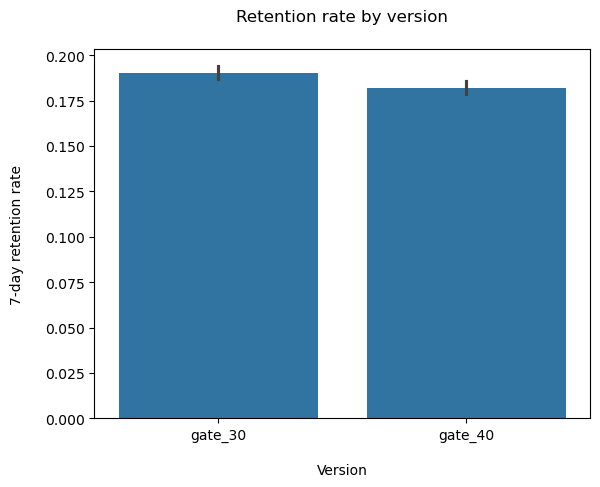

In [9]:
sns.barplot(
    data=ab_test,
    x='version',
    y='retention_7'
)

plt.title('Retention rate by version', pad=20)
plt.xlabel('Version', labelpad=15)
plt.ylabel('7-day retention rate', labelpad=15);

Через 7 днів після встановлення гри версія `gate_30` дає краще утримання (**коефіцієнт утримання 19.02 % проти 18.2 %**).

3. Перевірте з допомогою пасуючого варіанту z-тесту, чи дає якась з версій гри кращий показник `retention_7` на рівні значущості 0.05. Обчисліть також довірчі інтервали для варіантів до переміщення воріт і після. Виведіть результат у форматі:

    ```
    z statistic: ...
    p-value: ...
    Довірчий інтервал 95% для групи control: [..., ...]
    Довірчий інтервал 95% для групи treatment: [..., ...]
    ```

    де замість `...` - обчислені значення.
    
    В якості висновку дайте відповідь на два питання:  

      1. Чи є статистична значущою різниця між поведінкою користувачів у різних версіях гри?   
      2. Чи перетинаються довірчі інтервали утримання користувачів з різних версій гри? Про що це каже?  


In [10]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint

In [11]:
control_results = ab_test[
    ab_test['version'] == 'gate_30'
]['retention_7']

treatment_results = ab_test[
    ab_test['version'] == 'gate_40'
]['retention_7']

In [12]:
n_con = control_results.count()
n_treat = treatment_results.count()

nobs = [n_con, n_treat]
nobs

[np.int64(44700), np.int64(45489)]

In [13]:
successes = [
    control_results.sum(),
    treatment_results.sum()
]

successes

[np.int64(8502), np.int64(8279)]

In [14]:
z_stat, p_value = proportions_ztest(successes, nobs)

(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(
    successes,
    nobs=nobs,
    alpha=0.05,
    method='wilson'
)

print(f'z statistic: {z_stat:.3f}')
print(f'p-value: {p_value:.4f}')

print(
    f'Довірчий інтервал 95 % для групи control: '
    f'[{lower_con:.4f}, {upper_con:.4f}]'
)

print(
    f'Довірчий інтервал 95 % для групи treatment: '
    f'[{lower_treat:.4f}, {upper_treat:.4f}]'
)

z statistic: 3.164
p-value: 0.0016
Довірчий інтервал 95 % для групи control: [0.1866, 0.1939]
Довірчий інтервал 95 % для групи treatment: [0.1785, 0.1856]


**Висновок:**
- A. Оскільки p-value = 0.0016, а рівень значущості $\alpha$ = 0.05, то:
  - p-value < $\alpha$;
  - нульову гіпотезу ($H_0$) відхиляємо. Отже, різниця в поведінці користувачів у різних версіях гри є статистично значущою.
- B. Довірчі інтервали утримання користувачів у різних версіях гри не перетинаються, оскільки верхня межа `treatment` (0.1856) менша за нижню межу `control` (0.1866). Це свідчить про те, що різниця між групами є помітною та стабільною, утримання користувачів у групі `control` вище, ніж у `treatment`, а результат статистичного тесту підтверджується довірчим інтервалом.

4. Виконайте тест Хі-квадрат на рівні значущості 5% аби визначити, чи є залежність між версією гри та утриманням гравця на 7ий день після реєстрації.

    - Напишіть, як для цього тесту будуть сформульовані гіпотези.
    - Проведіть обчислення, виведіть p-значення і напишіть висновок за результатами тесту.


**Сформульовані гіпотези:**
- $H_0$: `version` ⟂ `retention_7` (незалежні змінні) - версія гри НЕ впливає на утримання гравця на 7-й день після реєстрації;
- $H_a$: `version` ∉⊥ `retention_7` (залежні змінні) - версія гри ВПЛИВАЄ на утримання гравця на 7-й день після реєстрації.

In [15]:
contingency_table = pd.crosstab(
    ab_test['version'],
    ab_test['retention_7']
)

contingency_table

retention_7,False,True
version,,
gate_30,36198,8502
gate_40,37210,8279


In [16]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print(f'χ² statistic: {chi2:.3f}')
print(f'p-value: {p_value:.4f}')
print(f'Ступені свободи: {dof}')
print(f'Очікувані частоти:\n {expected.round(2)}')

χ² statistic: 9.959
p-value: 0.0016
Ступені свободи: 1
Очікувані частоти:
 [[36382.9  8317.1]
 [37025.1  8463.9]]


**Висновок:** За результатами тесту відхиляємо $H_0$, оскільки p-value < $\alpha$ (0.0016 < 0.05). Отже, існує залежність між версією гри та утриманням гравця на 7-й день після реєстрації. Отримали той самий результат, що і з Z-test: статистично значуща різниця є.